# MA-XRF refactored 

*Rethinking our dashboard code we need to be able to explore and annotate the hotmax spectra for regions of interest.*

First run **Functions** code cells below. 

In [2]:
print(f'falnama: {fn.__version__}\nmaxrf4u: {mx.__version__}') 

falnama: 0.0.1
maxrf4u: 0.1.42


## Overview of all datastacks

In [3]:
data = fn.Falnama_maxrf_data()

data.get_base_path()

datastack_files = data.get_datastack_files()
datastack_files

['/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-01_400_600_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-03_250_300_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-08_250_300_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-10_250_300_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-12_250_300_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-13_400_600_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-17_400_600_50.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-18_400_300_50_det.datastack',
 '/media/frank/lonprojecten/2024-811_falnama-project

In [4]:
%matplotlib inline

In [5]:
imvis_list = []
extent_list = []
for datastack_file in datastack_files: 
    ds = mx.DataStack(datastack_file)
    im = ds.read('imvis_reg')
    extent = ds.read('imvis_extent')
    imvis_list.append(im)
    extent_list.append(extent)

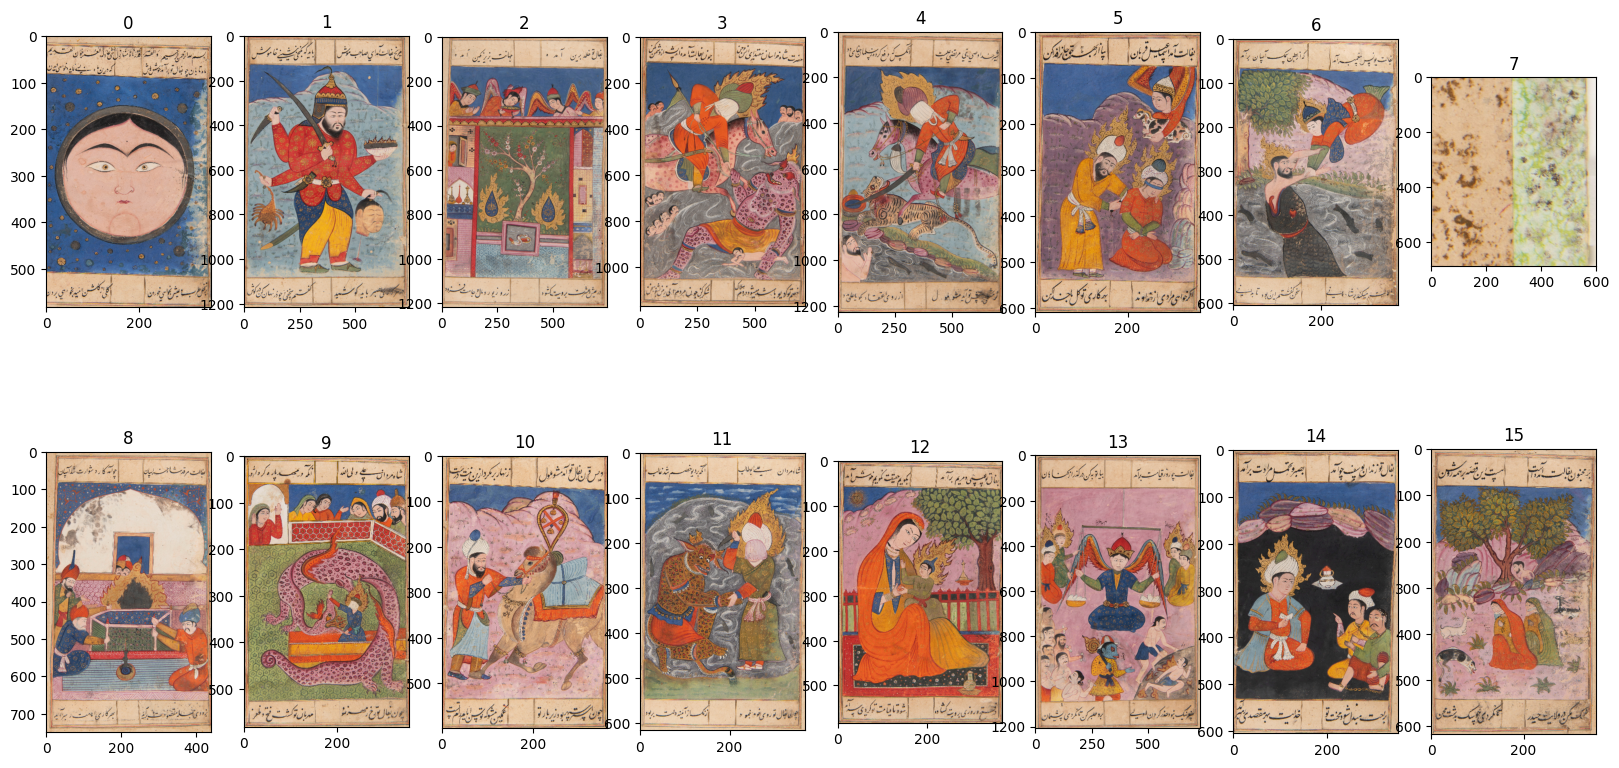

In [6]:
fig, axs = plt.subplots(ncols=8, nrows=2, figsize=[20, 10])
axs = axs.flatten()
for i, [im, ax, extent] in enumerate(zip(imvis_list, axs, extent_list)): 
    ax.imshow(im, extent=extent)
    ax.set_title(i)

In [7]:
n = 15
datastack_file = datastack_files[n]
ds = mx.DataStack(datastack_file)

cube = ds.read('maxrf_cube', compute=False)
imvis_highres = ds.read('imvis_reg_highres')
imvis = ds.read('imvis_reg')
extent = ds.read('imvis_extent')
x_keVs = ds.read('maxrf_energies')
y_maxspectrum = ds.read('maxrf_maxspectrum')

ds.tree()

/
├── compton_peak_energy (1,) float64
├── hotmax_baselines (31, 4096) float64
├── hotmax_noiselines (31, 4096) float64
├── hotmax_peak_idxs_flat (34,) int64
├── hotmax_peak_idxs_list (31, 2) int64
├── hotmax_spectra (31, 4096) float32
├── hotmax_spots (31, 2) int64
├── hotmax_subpeak_idxs_list (31, 18) int64
├── imvis_extent (4,) int64
├── imvis_reg (617, 357, 3) uint8
├── imvis_reg_highres (8256, 4777, 3) uint8
├── maxrf_cube (617, 357, 4096) float32
├── maxrf_energies (4096,) float64
├── maxrf_maxspectrum (4096,) float32
├── maxrf_sumspectrum (4096,) float64
├── nmf_atomnums (18,) int64
├── nmf_elementmaps (18, 617, 357) float32
├── nmf_gausscomponents (35, 4096) float32
├── nmf_peakmaps (35, 617, 357) float32
└── nmf_peaks2elements_matrix (18, 34) float32

/media/frank/lonprojecten/2024-811_falnama-project/data/interim/maxrf/datastacks/WM-71803-35_400_500_50.datastack:




## Regions of interest for page 35 (index 15)

A question is here if we need a more generic approach with boolean masks? 

In [9]:
# uncomment and run this cell to create regions of interest
#fig, axs = plt.subplots(ncols=3, figsize=[20, 8], squeeze=True)
#for ax in axs: 
#    ax.imshow(imvis_highres, extent=extent)

In [10]:
# xylims_list = [[int(ax.get_xlim()[0]), int(ax.get_xlim()[1]), int(ax.get_ylim()[0]), int(ax.get_ylim()[1])] for ax in axs]

In [11]:
xylims_list = [[140, 162, 464, 435], [137, 151, 398, 385], [250, 268, 461, 436], [93, 127, 458, 435], [60, 86, 292, 268], [33, 58, 101, 83]]
len(xylims_list)

6

In [12]:
roi_cubes = [cube[l:k, i:j].compute() for i, j, k, l in xylims_list]

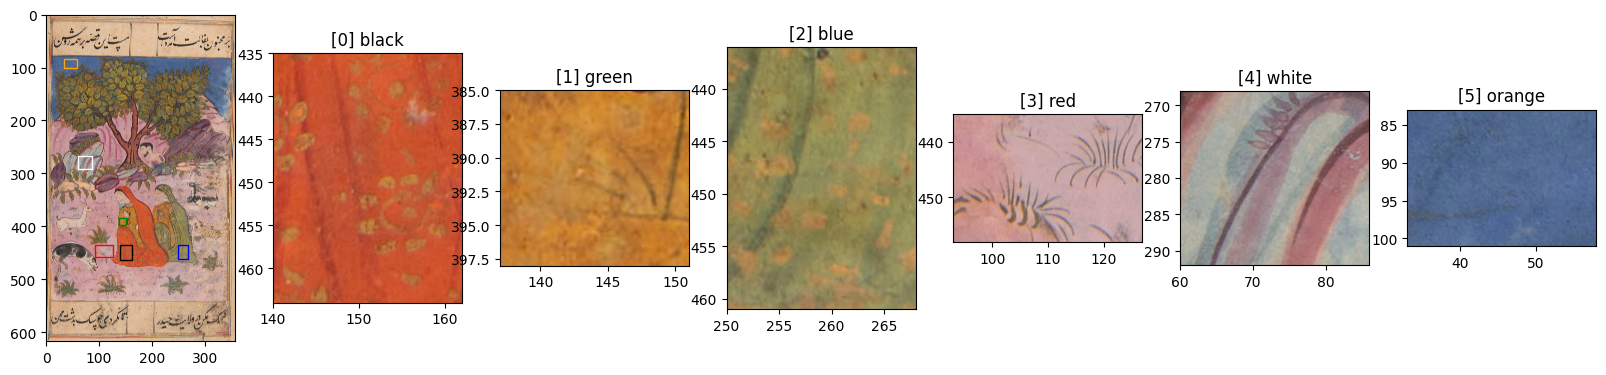

In [14]:
fig, axs = plt.subplots(ncols=7, figsize=[20, 8], squeeze=True)

edgecolors = ['black', 'green', 'blue', 'red', 'white', 'orange']

axs[0].imshow(imvis_highres, extent=extent)

for i, xylims in enumerate(xylims_list):
    x0, x1, y0, y1 = xylims
    axs[0].add_patch(Rectangle([x0, y1], x1 -x0, y0 - y1, linewidth=1, edgecolor=edgecolors[i], facecolor='none'))


for i, ax in enumerate(axs[1:]): 
    
    ax.imshow(imvis_highres, extent=extent)
    ax.set_xlim(xylims_list[i][0:2])
    ax.set_ylim(xylims_list[i][2:4])
    ax.set_title(f'[{i}] {edgecolors[i]}')
    

## Exploring region #0

In [15]:
roi_n = 0
hotmax_idxs, spectra = get_hotmax_spectra(roi_cubes[roi_n])

### Region hotmax spectra 

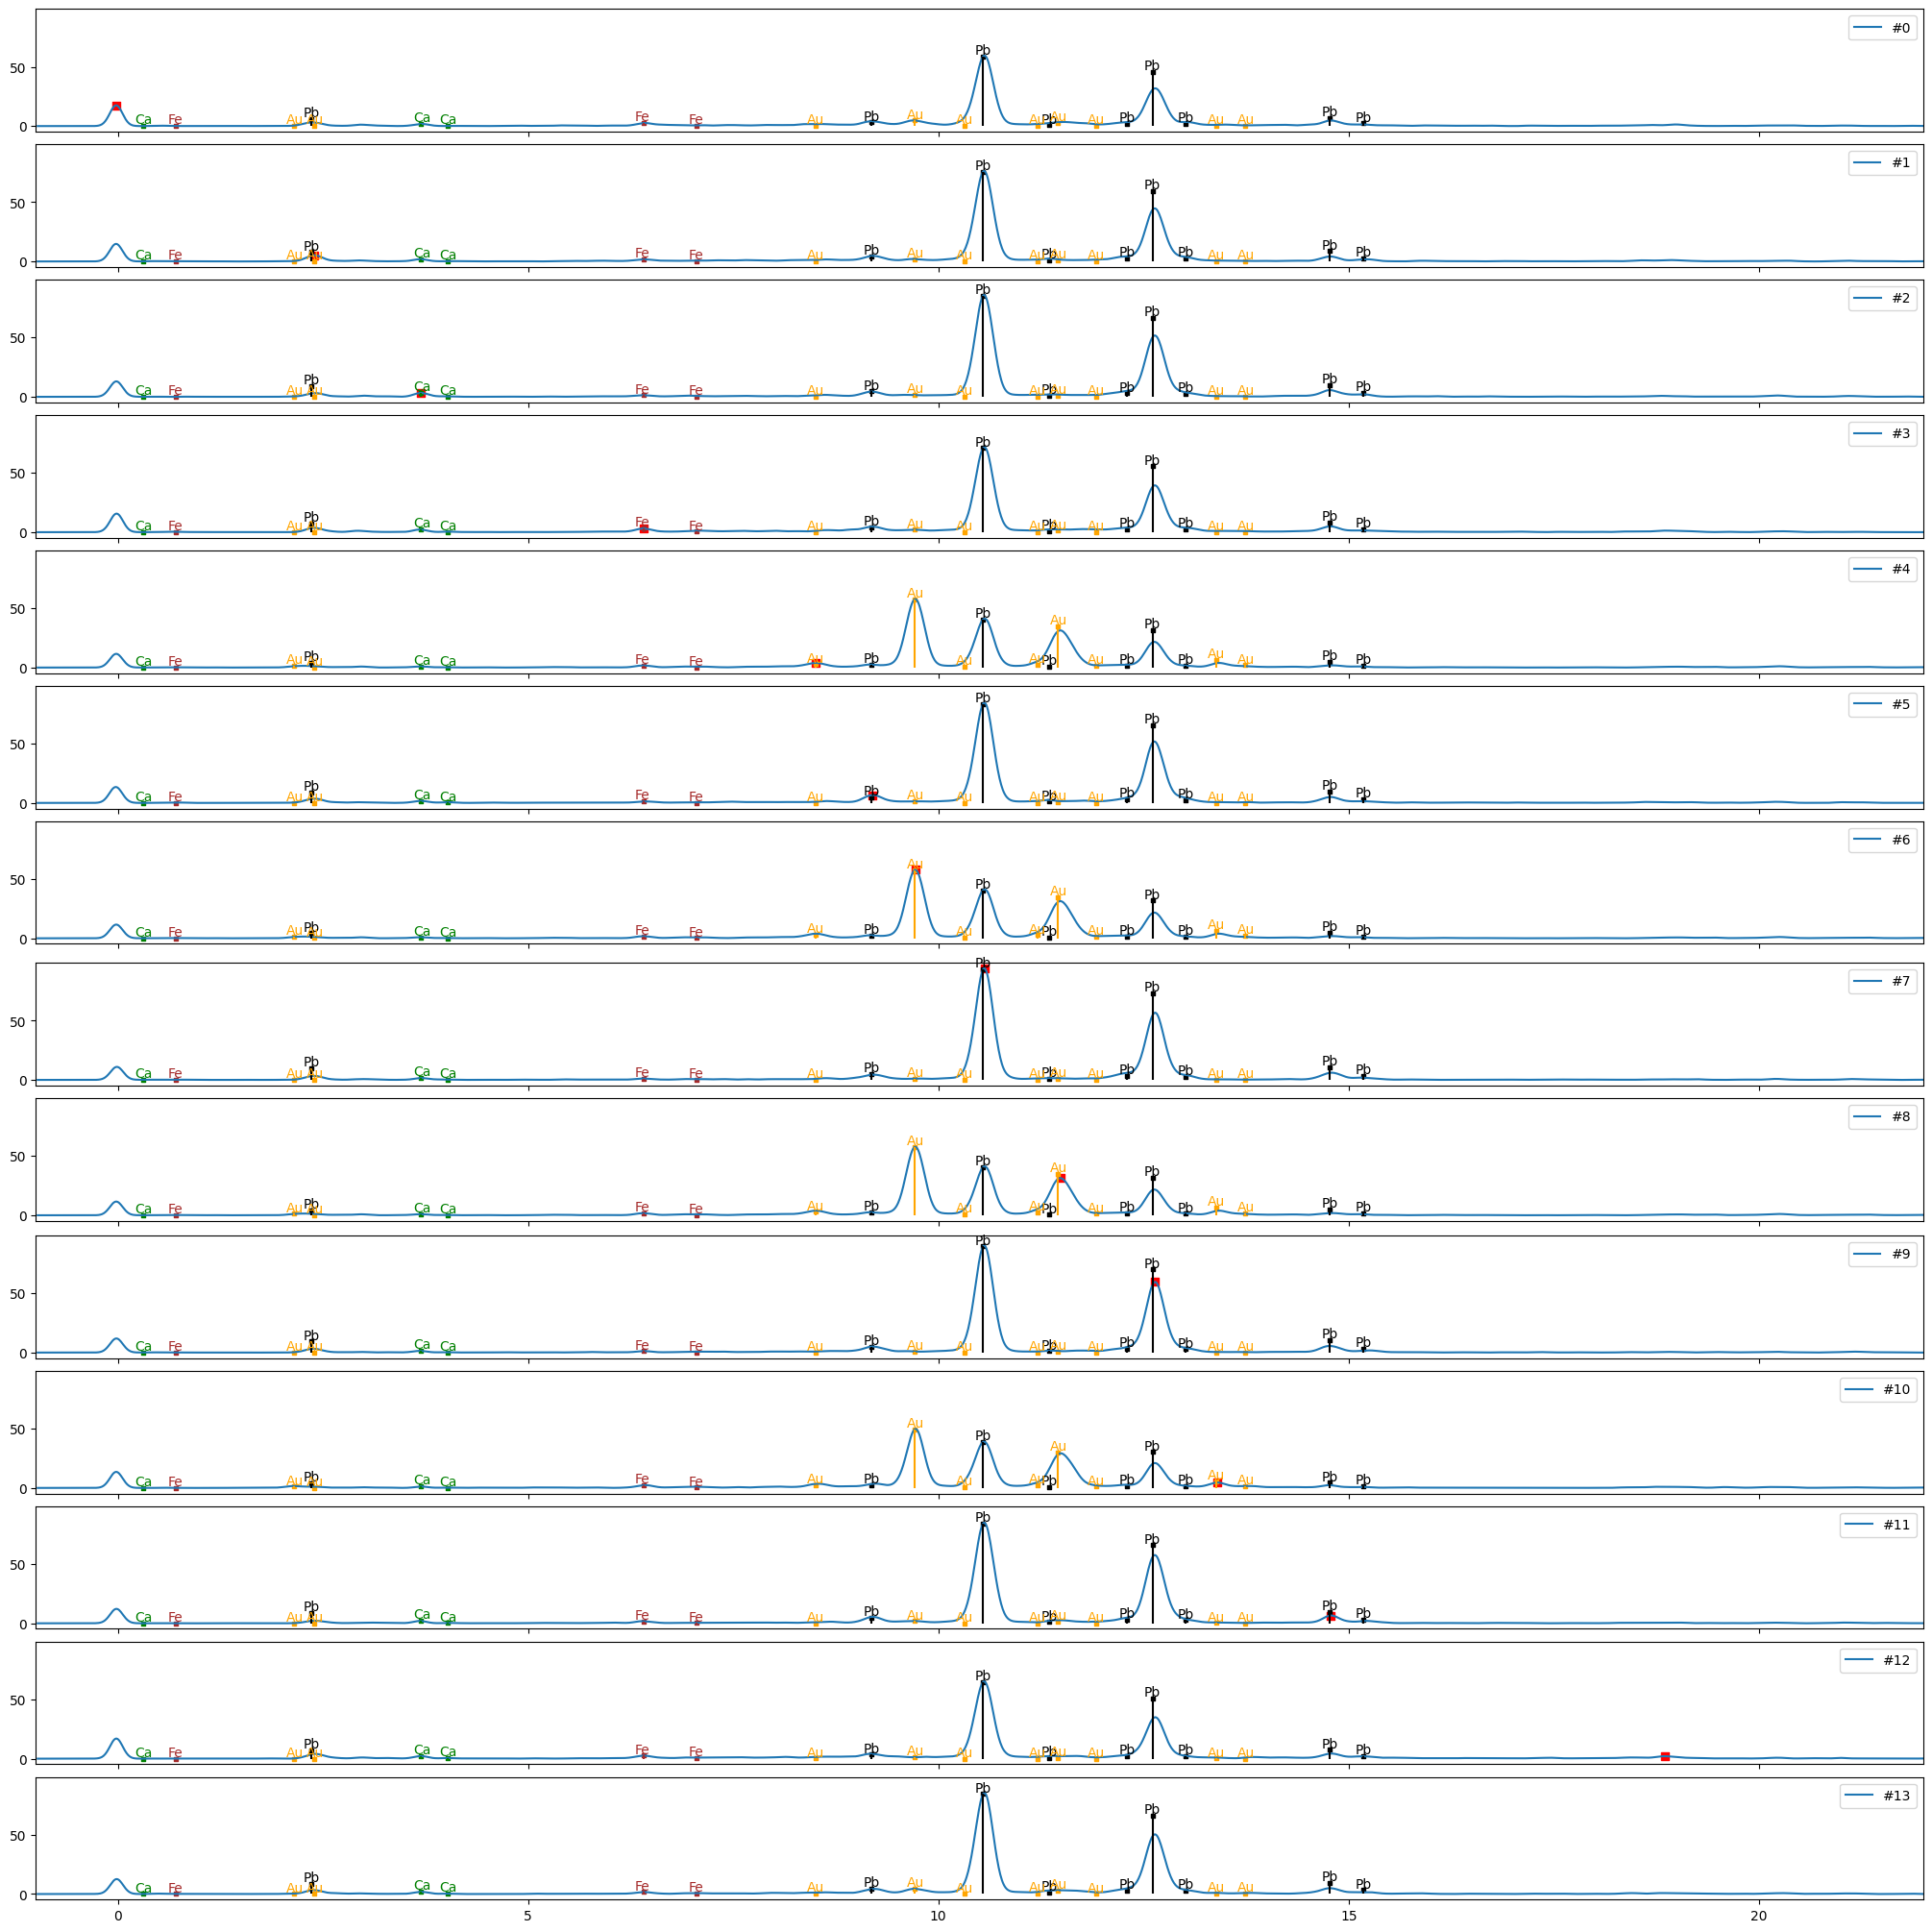

In [16]:
elements = ['Pb', 'Au', 'Ca', 'Fe']
spectra_axs = plot_hotmax_spectra(spectra, x_keVs, hotmax_idxs, elems=elements) 

### Region alpha element maps  

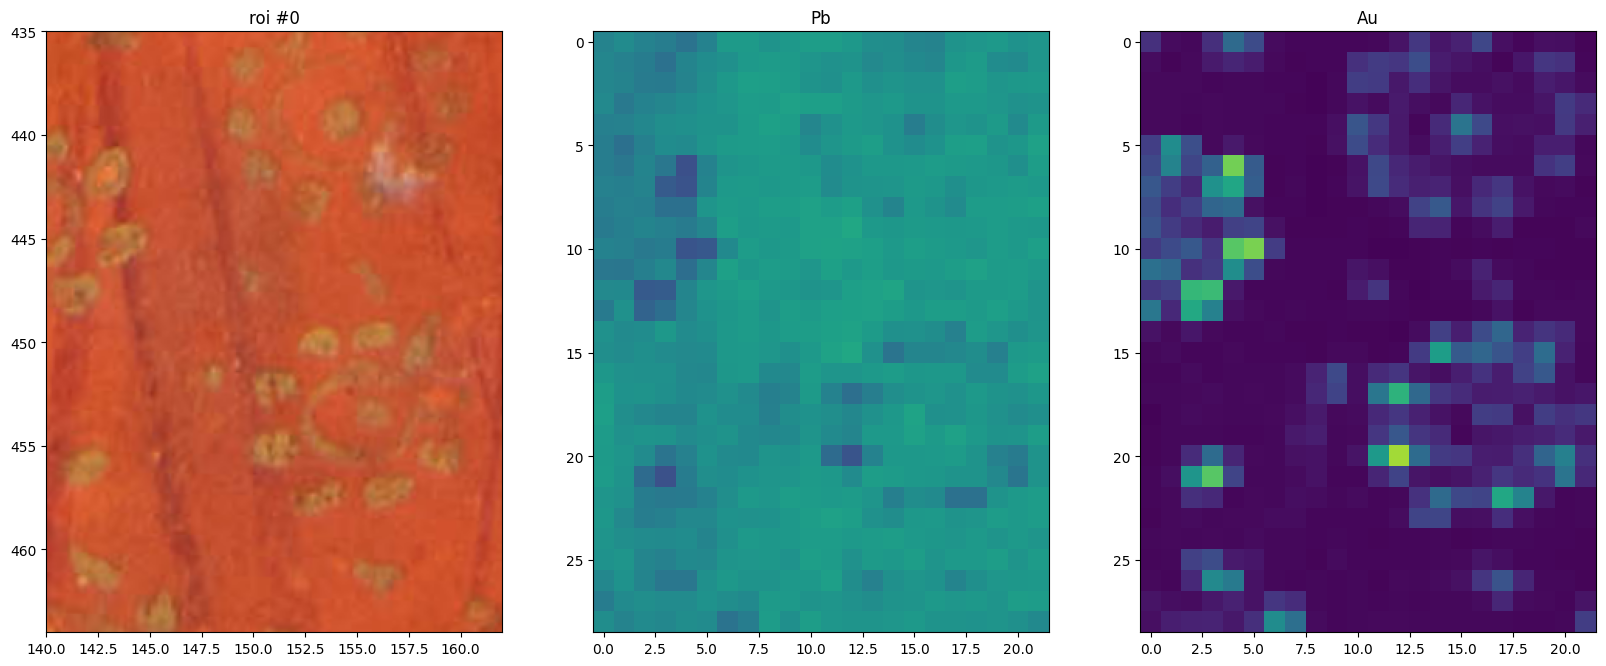

In [17]:
elements = ['Pb', 'Au'] 

alpha_idxs, roi_maps = get_roi_maps(roi_cubes[roi_n], ['Pb', 'Au'], x_keVs)

plot_roi_maps(roi_cubes, xylims_list, roi_n, elements, y_maxspectrum=y_maxspectrum)

## Exploring region #1

Ok, next...

## Functions 

In [1]:
import falnama as fn
import matplotlib.pyplot as plt
import maxrf4u as mx  
import moseley as mos
import numpy as np
import scipy.signal as ssg 
import matplotlib.cm as cm
import skimage.exposure as ske
from matplotlib.patches import Rectangle 

elem_colors = {'Pb': 'k', 'Au': 'orange', 'Fe': 'brown', 'Ca': 'g', 'K': 'b'}

def get_hotmax_spectra(roi_cube): 
    '''Get hotmax spectra for `roi_cube`. 
    
    Returns: `hotspot_idxs, `spectra` 
    '''

    hotmax_idxs = []
    spectra = []
    
    n_channels = roi_cube.shape[-1]
    y_max = roi_cube.reshape([-1, n_channels]).max(axis=0) 
    peak_idxs = ssg.find_peaks(y_max, prominence=1)[0] 
    
    for p_i in peak_idxs: 
        peak_slice = roi_cube[:,:, p_i]
        i, j = np.argwhere(peak_slice == peak_slice.max())[0]
   
        y = roi_cube[i, j]
        
        spectra.append(y)
        hotmax_idxs.append([int(i), int(j), int(p_i)])

    hotmax_idxs = np.array(hotmax_idxs)

    return hotmax_idxs, spectra 


def plot_hotmax_spectra(spectra, x_keVs, hotmax_idxs, elems=None, xlim=[-1, 22], elem_colors=elem_colors, y_maxspectrum=None):
    '''Plot roi hotmax spectra and add emission lines for list of elements `elems`. 

    Returns: axs 
    '''

    peak_idxs = hotmax_idxs[:, 2] 
    
    fig, axs = plt.subplots(nrows=len(spectra), sharex=True, sharey=True, figsize=[20, 20], squeeze=True, layout='compressed')
    
    for i, y in enumerate(spectra): 
        axs[i].set_xlim(xlim)
        if y_maxspectrum is not None: 
            axs[i].plot(x_keVs, y_maxspectrum, color='r', alpha=0.1)
        axs[i].plot(x_keVs, y, label=f'#{i}')
        axs[i].scatter(x_keVs[peak_idxs[i]], y[peak_idxs[i]], marker='s', color='r')
        axs[i].legend()
    
        if elems is not None: 
            for elem in elems: 
            
                plot_element_lines(elem, y=y, ax=axs[i], x_keVs=x_keVs, color=elem_colors[elem])

    return axs    

def get_element_lines(element, x_keVs, exc_keV=23): 
    '''Get sorted element peak idxs. '''
    
    elem_y = mx.get_element_spectrum(element, exc_keV, x_keVs=x_keVs)
    peak_idxs = ssg.find_peaks(elem_y)[0]
    peak_idxs = np.array([int(idx) for idx in peak_idxs])
    peaks_x = x_keVs[peak_idxs]
    peaks_y = elem_y[peak_idxs] 

    sort_idxs = np.argsort(peaks_y)
    peak_idxs_sorted = peak_idxs[sort_idxs][::-1] 

    return peak_idxs_sorted

    
def plot_element_lines(element, x_keVs, y=None, ax=None, exc_keV=23, color=None): 
    '''Add emission lines to spectral plot. '''

    if ax == None: 
        fig, ax = plt.subplots(figsize=[15, 5])
        
    if color == None: 
        color = mx.colorize(element)
    
    elem_y = mx.get_element_spectrum(element, exc_keV, x_keVs=x_keVs)
    peak_idxs = ssg.find_peaks(elem_y)[0]
    #peak_idxs = np.array([int(idx) for idx in peak_idxs])
    peaks_x = x_keVs[peak_idxs]
    peaks_y = elem_y[peak_idxs] 

    sort_idxs = np.argsort(peaks_y)
    peak_idxs_sorted = peak_idxs[sort_idxs][::-1] 

    peak_idxs_sorted = get_element_lines(element, x_keVs)
    
    if y is not None: 
        alpha_idx = peak_idxs_sorted[0]
        y_alpha  = y[alpha_idx]
        peaks_y = peaks_y * y_alpha
    
    ax.vlines(peaks_x, np.zeros_like(peaks_y), peaks_y, color=color)
    ax.scatter(peaks_x, peaks_y, marker='s', s=8, color=color)
    
    for x, y in zip(peaks_x, peaks_y): 
        ax.annotate(element, [x-0.1, y + 2], color=color) 

    return peak_idxs_sorted 

def get_roi_maps(roi_cube, elements, x_keVs, exc_keV=23): 
    'Slice roi cube at alpha index positions'

    roi_maps = []
    alpha_idxs = []
    

    for elem in elements: 

        sorted_peak_idxs = get_element_lines(elem, x_keVs, exc_keV)
        alpha_idx = sorted_peak_idxs[0]
        roi_map = roi_cube[:,:,alpha_idx]
        roi_maps.append(roi_map)
        alpha_idxs.append(int(alpha_idx))

    return alpha_idxs, roi_maps
    

def plot_roi_maps(roi_cubes, xylims_list, roi_n, elements, y_maxspectrum=None, exc_keV=23): 
    '''Plot full cube max spectrum normalized roi maps. '''

    alpha_idxs, roi_maps = get_roi_maps(roi_cubes[roi_n], elements, x_keVs, exc_keV=exc_keV)

    fig, axs = plt.subplots(ncols=len(elements) + 1, squeeze=True, figsize=[20, 10])
    

    axs[0].imshow(imvis_highres, extent=extent)
    axs[0].set_xlim(xylims_list[roi_n][0:2])
    axs[0].set_ylim(xylims_list[roi_n][2:4])
    axs[0].set_title(f'roi #{roi_n}')
    
    for ax, roi_map, elem, alpha_idx in zip(axs[1:], roi_maps, elements, alpha_idxs): 
        if y_maxspectrum is not None: 
            vmax = y_maxspectrum[alpha_idx]
        else: 
            vmax = None 
        ax.imshow(roi_map, vmin=0, vmax=vmax)
        ax.set_title(elem)
         